# IRI full trigger modeling

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *

In [5]:
blob_name = "ds-aa-ner-drought/raw/iri/ner_maproom_export_2026-04-25_thresh35 - Sheet1.csv"
df_stats_iri = stratus.load_csv_from_blob(blob_name)
df_stats_iri.columns = ["year"] + [
    calendar.month_abbr[x] for x in [y for y in range(1, 7)] + [8]
]
df_stats_iri["year"] = df_stats_iri["year"].astype(int)

In [6]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Aug
0,2025,12.0,17.3,13.9,8.7,11.7,10.9,0.466
1,2024,16.2,12.9,12.7,15.4,19.3,14.6,1.304
2,2023,24.1,25.8,28.2,30.3,29.5,30.3,-0.201
3,2022,17.7,12.7,15.3,14.9,16.5,21.4,-0.512
4,2021,9.6,4.8,10.4,13.4,15.8,18.8,0.378
5,2020,11.7,10.0,10.8,12.5,14.4,18.2,0.137
6,2019,19.3,25.7,28.5,26.5,26.7,21.2,-0.293
7,2018,15.0,18.5,17.8,20.8,18.2,16.2,0.355
8,2017,29.3,28.1,35.0,23.9,24.7,26.0,0.586
9,2016,16.6,23.2,13.5,10.4,14.7,16.6,0.783


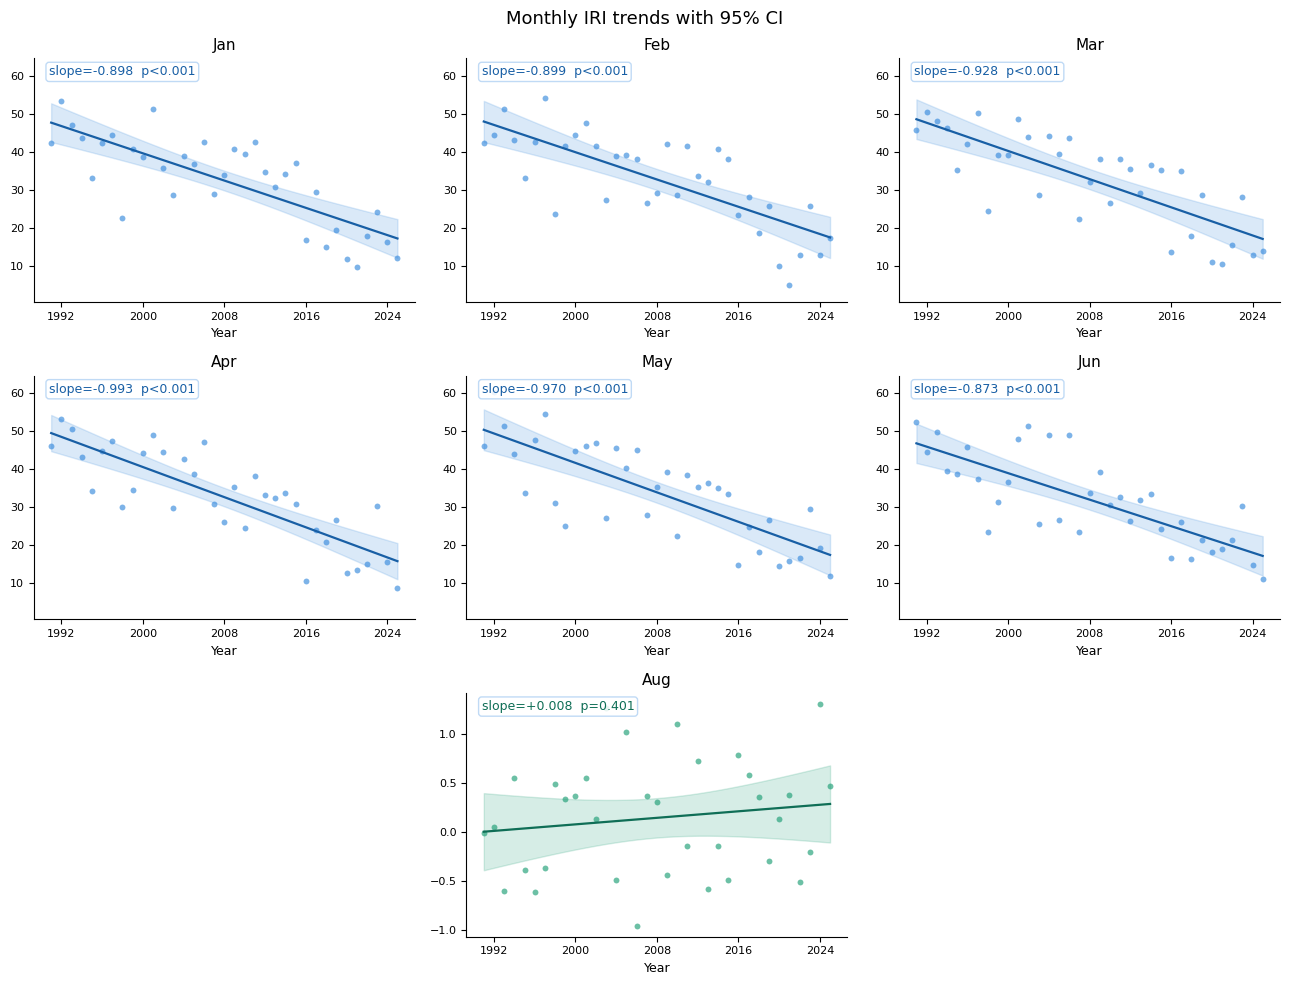

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats


def plot_trend(ax, x, y, color_scatter, color_line, color_band):
    slope, intercept, r, p, se = stats.linregress(x, y)
    y_hat = intercept + slope * x
    n = len(x)
    x_mean = x.mean()
    t_crit = stats.t.ppf(0.975, df=n - 2)
    s_err = np.sqrt(np.sum((y - y_hat) ** 2) / (n - 2))
    ci = (
        t_crit
        * s_err
        * np.sqrt(1 / n + (x - x_mean) ** 2 / np.sum((x - x_mean) ** 2))
    )

    ax.scatter(
        x, y, s=18, color=color_scatter, alpha=0.65, zorder=3, linewidths=0
    )
    ax.plot(x, y_hat, color=color_line, lw=1.6, zorder=4)
    ax.fill_between(
        x, y_hat - ci, y_hat + ci, color=color_band, alpha=0.18, zorder=2
    )

    p_label = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
    ax.annotate(
        f"slope={slope:+.3f}  {p_label}",
        xy=(0.04, 0.93),
        xycoords="axes fraction",
        fontsize=9,
        color=color_line,
        bbox=dict(
            boxstyle="round,pad=0.25", fc="white", ec="#B5D4F4", alpha=0.85
        ),
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Year", fontsize=9)


months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

fig = plt.figure(figsize=(13, 10))
fig.suptitle("Monthly IRI trends with 95% CI", fontsize=13, fontweight="500")

axes_main = [
    plt.subplot2grid((3, 3), (row, col))
    for row in range(2)
    for col in range(3)
]

y_all = np.concatenate([df_stats_iri[col].dropna().values for col in months])
y_pad = (y_all.max() - y_all.min()) * 0.08
y_lo, y_hi = y_all.min() - y_pad, y_all.max() + y_pad

for ax, col in zip(axes_main, months):
    mask = df_stats_iri[col].notna()
    x = df_stats_iri.loc[mask, "year"].values
    y = df_stats_iri.loc[mask, col].values
    plot_trend(ax, x, y, "#378ADD", "#185FA5", "#378ADD")
    ax.set_title(col, fontsize=11, fontweight="500")
    ax.set_ylim(y_lo, y_hi)

# Aug: center column only
ax_aug = plt.subplot2grid((3, 3), (2, 1))
mask = df_stats_iri["Aug"].notna()
x_aug = df_stats_iri.loc[mask, "year"].values
y_aug = df_stats_iri.loc[mask, "Aug"].values
plot_trend(ax_aug, x_aug, y_aug, "#1D9E75", "#0F6E56", "#1D9E75")
ax_aug.set_title("Aug", fontsize=11, fontweight="500")

# hide the two flanking bottom cells
plt.subplot2grid((3, 3), (2, 0)).set_visible(False)
plt.subplot2grid((3, 3), (2, 2)).set_visible(False)

fig.tight_layout()
plt.savefig("iri_monthly_trends.png", dpi=150, bbox_inches="tight")
plt.show()

<Axes: xlabel='year'>

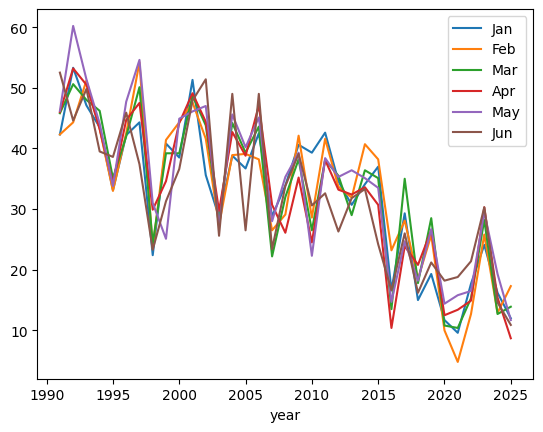

In [9]:
df_stats_iri.drop(columns="Aug").plot(x="year")

In [10]:
start_year = 1998
end_year = 2025
total_years = end_year - start_year + 1

In [22]:
rp_target = 3.5
n_years_overall_target = int((total_years + 1) / rp_target)

In [23]:
n_years_overall_target

8

In [24]:
actual_rp = (total_years + 1) / n_years_overall_target
actual_rp

3.625

In [25]:
(total_years + 1) / (n_years_overall_target + 1)

3.2222222222222223

In [26]:
(total_years + 1) / (n_years_overall_target - 1)

4.142857142857143

In [27]:
quantiles = np.arange(0.05, 1, 0.05)
quantiles = [round(x, 2) for x in quantiles]

In [28]:
mos = [1, 2, 3, 4, 5, 6]

In [55]:
dfs = []
for quantile in quantiles:
    df_q = pd.DataFrame(columns=["year"])
    for mo in mos:
        col = calendar.month_abbr[mo]
        dicts = []
        for current_year in range(start_year, end_year + 1):
            df_past = df_stats_iri[df_stats_iri["year"] <= current_year]
            if df_past.empty:
                continue

            current_row = df_stats_iri.set_index("year").loc[current_year]

            thresh = df_past[col].quantile(1 - quantile)
            trig = current_row[col] >= thresh

            dicts.append(
                {
                    "year": current_year,
                    f"thresh_{mo}": thresh,
                    f"trig_{mo}": trig,
                }
            )

        df_wf_trigs = pd.DataFrame(dicts)
        df_q = df_q.merge(df_wf_trigs, on="year", how="outer")
    df_q["q"] = quantile

    consec_cols = []
    for second_mo in mos[1:]:
        first_mo = second_mo - 1
        consec_col = f"trig_{first_mo}_{second_mo}"
        df_q[consec_col] = df_q[f"trig_{first_mo}"] & df_q[f"trig_{second_mo}"]
        consec_cols.append(consec_col)

    df_q["trig_fcast"] = df_q[consec_cols].any(axis=1)
    dfs.append(df_q)

df_qs = pd.concat(dfs, ignore_index=True)
df_qs = df_qs.merge(df_stats_iri[["year", "Aug"]])

In [60]:
df_old_qs = df_qs[df_qs["q"] == 0.3]

df_disp = df_old_qs.copy()
df_disp = df_disp.sort_values("year", ascending=False)
df_disp.set_index("year")[
    [x for x in df_disp.columns if "trig_" in x]
].style.map(highlight_true)

,trig_1,trig_2,trig_3,trig_4,trig_5,trig_6,trig_1_2,trig_2_3,trig_3_4,trig_4_5,trig_5_6,trig_fcast
year,,,,,,,,,,,,
2025,False,False,False,False,False,False,False,False,False,False,False,False
2024,False,False,False,False,False,False,False,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False
2022,False,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False,False
2020,False,False,False,False,False,False,False,False,False,False,False,False
2019,False,False,False,False,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False,False,False,False,False
2017,False,False,False,False,False,False,False,False,False,False,False,False


In [57]:
dicts = []
for n_target in (
    n_years_overall_target - 1,
    n_years_overall_target,
    n_years_overall_target + 1,
):
    print(f"\n{'='*50}")
    print(f"=== n_target: {n_target} ===")
    print(f"{'='*50}")
    for quantile, group in df_qs.groupby("q"):
        print(f"\n  Forecast quantile: {quantile}")
        for obsv_q in quantiles:
            obsv_thresh = df_stats_iri["Aug"].quantile(obsv_q)
            group["trig_obsv"] = group["Aug"] <= obsv_thresh
            group["trig_either"] = group[["trig_fcast", "trig_obsv"]].any(
                axis=1
            )
            count_trig = group["trig_either"].sum()
            if count_trig == n_target:
                print(
                    f"    ✓ Match at obsv_q={obsv_q} (thresh={obsv_thresh:.3f})"
                )
                for w in ["fcast", "obsv", "either"]:
                    col = f"trig_{w}"
                    years = sorted(group[group[col]]["year"].unique())
                    print(f"    {w:>6}: n={group[col].sum()}  years={years}")
                dicts.append(
                    {
                        "n_target": n_target,
                        "q": quantile,
                        "obsv_q": obsv_q,
                        "n_fcast": group["trig_fcast"].sum(),
                        "n_obsv": group["trig_obsv"].sum(),
                        "n_either": group["trig_either"].sum(),
                    }
                )
                break
            else:
                print(
                    f"    obsv_q={obsv_q} (thresh={obsv_thresh:.3f}): count={count_trig} (need {n_target})"
                )
        else:
            print(f"    ✗ No match found for any obsv_q")

df_counts = pd.DataFrame(dicts)


=== n_target: 7 ===

  Forecast quantile: 0.05
    obsv_q=0.05 (thresh=-0.601): count=1 (need 7)
    obsv_q=0.1 (thresh=-0.550): count=2 (need 7)
    obsv_q=0.15 (thresh=-0.484): count=4 (need 7)
    obsv_q=0.2 (thresh=-0.447): count=5 (need 7)
    obsv_q=0.25 (thresh=-0.374): count=6 (need 7)
    ✓ Match at obsv_q=0.3 (thresh=-0.275)
     fcast: n=0  years=[]
      obsv: n=7  years=[np.int64(2004), np.int64(2006), np.int64(2009), np.int64(2013), np.int64(2015), np.int64(2019), np.int64(2022)]
    either: n=7  years=[np.int64(2004), np.int64(2006), np.int64(2009), np.int64(2013), np.int64(2015), np.int64(2019), np.int64(2022)]

  Forecast quantile: 0.1
    obsv_q=0.05 (thresh=-0.601): count=1 (need 7)
    obsv_q=0.1 (thresh=-0.550): count=2 (need 7)
    obsv_q=0.15 (thresh=-0.484): count=4 (need 7)
    obsv_q=0.2 (thresh=-0.447): count=5 (need 7)
    obsv_q=0.25 (thresh=-0.374): count=6 (need 7)
    ✓ Match at obsv_q=0.3 (thresh=-0.275)
     fcast: n=0  years=[]
      obsv: n=7  years

In [58]:
df_counts

,n_target,q,obsv_q,n_fcast,n_obsv,n_either
0,7,0.05,0.30,0,7,7
1,7,0.10,0.30,0,7,7
2,7,0.15,0.30,0,7,7
3,7,0.20,0.25,1,6,7
4,7,0.25,0.25,1,6,7
5,7,0.30,0.25,1,6,7
6,7,0.35,0.25,1,6,7
7,7,0.40,0.20,2,5,7
8,7,0.45,0.15,3,4,7
9,7,0.55,0.10,6,2,7


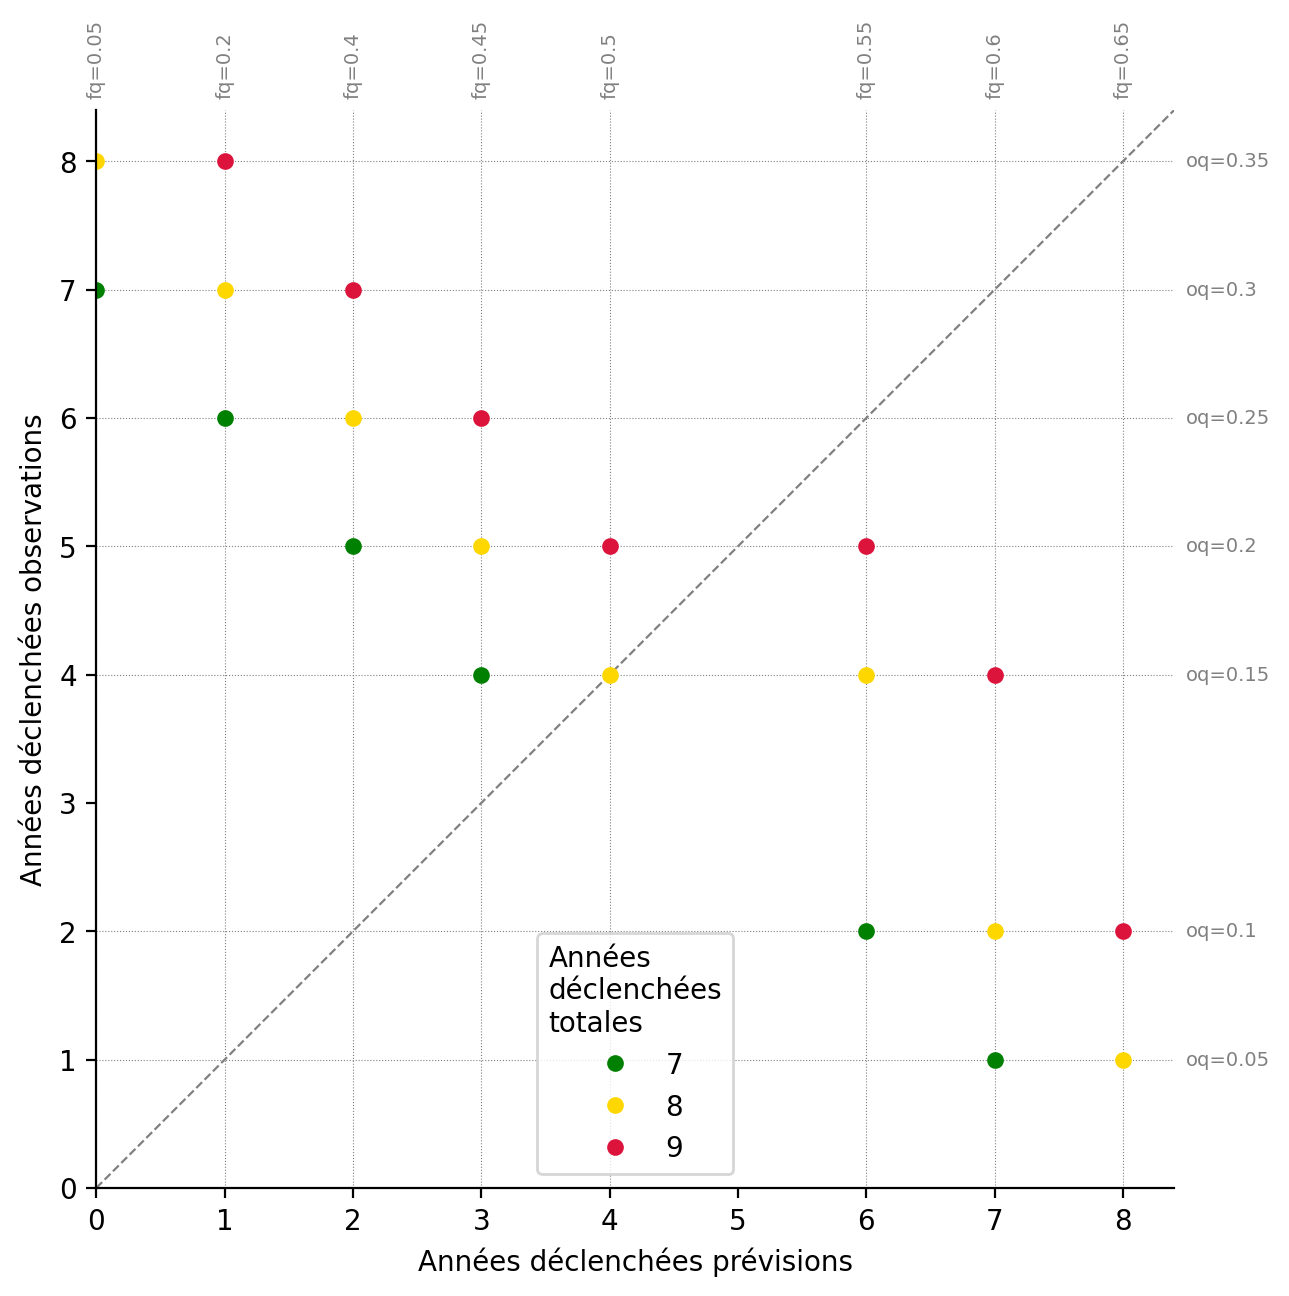

In [62]:
import matplotlib.colors as mcolors

df_counts = pd.DataFrame(dicts)
pivot = df_counts.pivot_table(
    columns="n_target", index="n_fcast", values="n_obsv"
)

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

n_targets = sorted(df_counts["n_target"].unique())
colors = ["green", "gold", "crimson"]
for col, color in zip(n_targets, colors):
    pivot[col].plot(
        marker=".",
        linewidth=0,
        ax=ax,
        markersize=10,
        color=color,
        label=str(col),
    )

lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color="grey", linewidth=0.8, linestyle="--", zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

for _, row in df_counts.drop_duplicates("n_fcast").iterrows():
    ax.axvline(
        row["n_fcast"], color="grey", linewidth=0.4, linestyle=":", zorder=0
    )
    ax.annotate(
        f"fq={row['q']}",
        xy=(row["n_fcast"], lims[1]),
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=7,
        color="grey",
        ha="center",
        va="bottom",
        rotation=90,
        annotation_clip=False,
    )

for _, row in df_counts.drop_duplicates("n_obsv").iterrows():
    ax.axhline(
        row["n_obsv"], color="grey", linewidth=0.4, linestyle=":", zorder=0
    )
    ax.annotate(
        f"oq={row['obsv_q']}",
        xy=(lims[1], row["n_obsv"]),
        xytext=(4, 0),
        textcoords="offset points",
        fontsize=7,
        color="grey",
        ha="left",
        va="center",
        annotation_clip=False,
    )

ax.set_ylabel("Années déclenchées observations")
ax.set_xlabel("Années déclenchées prévisions")
ax.legend(title="Années\ndéclenchées\ntotales")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

In [63]:
sel_q = 0.55
sel_n_obsv = 4

In [64]:
df_sel_q = df_qs[df_qs["q"] == sel_q].copy()

In [65]:
# obsv_trig_year_count = df_counts.set_index("q").loc[sel_q]

In [66]:
# obsv_final_thresh = df_sel_q["Aug"].nsmallest(obsv_trig_year_count).max()
obsv_final_thresh = df_sel_q["Aug"].nsmallest(sel_n_obsv).max()

In [67]:
df_sel_q["Aug_trig"] = df_sel_q["Aug"] <= obsv_final_thresh

In [68]:
obsv_final_thresh

np.float64(-0.484)

In [69]:
obsv_trig_years = df_sel_q[df_sel_q["Aug_trig"]]["year"].unique()

In [70]:
obsv_trig_years

array([2004, 2006, 2013, 2022])

In [71]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""

In [72]:
def highlight_val(val: str, target: str = "Oui"):
    if val == target:
        return "background-color: crimson"
    return ""

In [73]:
df_disp = df_sel_q.copy()
df_disp = df_disp.sort_values("year", ascending=False)
df_disp.set_index("year")[
    [x for x in df_disp.columns if "trig_" in x]
].style.map(highlight_true)

,trig_1,trig_2,trig_3,trig_4,trig_5,trig_6,trig_1_2,trig_2_3,trig_3_4,trig_4_5,trig_5_6,trig_fcast
year,,,,,,,,,,,,
2025,False,False,False,False,False,False,False,False,False,False,False,False
2024,False,False,False,False,False,False,False,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False
2022,False,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False,False
2020,False,False,False,False,False,False,False,False,False,False,False,False
2019,False,False,False,False,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False,False,False,False,False
2017,False,False,False,False,False,False,False,False,False,False,False,False


In [74]:
df_sel_q.columns

Index(['year', 'thresh_1', 'trig_1', 'thresh_2', 'trig_2', 'thresh_3',
       'trig_3', 'thresh_4', 'trig_4', 'thresh_5', 'trig_5', 'thresh_6',
       'trig_6', 'q', 'trig_1_2', 'trig_2_3', 'trig_3_4', 'trig_4_5',
       'trig_5_6', 'trig_fcast', 'Aug', 'Aug_trig'],
      dtype='object')

In [75]:
df_disp = df_sel_q.merge(df_stats_iri)
df_disp = df_disp.sort_values("year", ascending=False)

fcast_col = "Déclenche<br>prévisions"
obsv_col = "Déclenche<br>observations"
badyears_col = "Classement de<br>mauvaises années"
cerf_col = "Montant allocation<br>CERF (USD)"

col_rename = {
    "year": "Année",
    # "Humanitarian Bad Years (rank)": badyears_col,
    # "Amount in US$": cerf_col,
    "trig_fcast": fcast_col,
    "Aug_trig": obsv_col,
}

trig_cols = [fcast_col, obsv_col]
numeric_cols = [badyears_col, cerf_col]
# cols = trig_cols + numeric_cols
cols = trig_cols

df_disp = df_disp.rename(columns=col_rename)

sty = (
    df_disp.set_index("Année")[cols]
    .style.map(highlight_true, subset=trig_cols)
    .format(
        {
            badyears_col: "{:,.0f}",
            cerf_col: "{:,.0f}",
        },
        na_rep="",
    )
    # .background_gradient(cmap="Purples_r", subset=[badyears_col])
    # .background_gradient(cmap="Reds", subset=[cerf_col])
    # override NaNs
    # .map(
    #     lambda v: "background-color: white;" if pd.isna(v) else "",
    #     subset=numeric_cols,
    # )
)

sty

,Déclencheprévisions,Déclencheobservations
Année,,
2025,False,False
2024,False,False
2023,False,False
2022,False,True
2021,False,False
2020,False,False
2019,False,False
2018,False,False
2017,False,False


In [151]:
(total_years + 1) / 8

3.5

In [152]:
(25 + 1) / 2

13.0

In [153]:
f"{2 / (25 + 1):.1%}"

'7.7%'

In [154]:
(25 + 1) / 5

5.2

In [155]:
f"{5 / (26 + 1):.0%}"

'19%'